# 『校則問題』を再考する
## —偏差値と校則の自由度に関する定量的分析—

大森一輝 / 一橋大学ソーシャル・データサイエンス学部２年 / 5125006H

---

### このノートブックについて
データハンドリングの期末レポートの補足資料として、実行コードをこのノートブックに記す。  
データ収集・前処理・形態素解析・アノテーション・スコア計算・統計分析・可視化の全工程を対象とする。

---

## 0. 環境設定

必要なライブラリをインストールし、インポートする。`japanize-matplotlib`は`matplotlib`で日本語を表示するために使用する。`statsmodels`は重回帰分析のために使用する。

In [337]:
!pip install requests -q
!pip install beautifulsoup4 -q
!pip install unidic-lite -q
!pip install mecab-python3 -q
!pip install japanize-matplotlib -q
!pip install statsmodels -q

In [338]:
import requests
from bs4 import BeautifulSoup
import time

import numpy as np
import pandas as pd
import MeCab

import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns
import japanize_matplotlib

from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

matplotlib.style.use('ggplot')

---

## 1.校則テキストの収集

### 1-1.HTMLの確認

requestsを使用して、全国校則一覧のwebページ情報を取得する。

In [339]:
r = requests.get('https://www.kousoku.org/')
text = r.text
print(text)

<!doctype html>
<html lang="ja">

<head>
<meta charset="utf-8">
<meta http-equiv="X-UA-Compatible" content="IE=edge">
<meta name="viewport" content="width=device-width, initial-scale=1.0, viewport-fit=cover"/>
<meta name="referrer" content="no-referrer-when-downgrade"/>


  
    <!-- Global site tag (gtag.js) - Google Analytics -->
    <script async src="https://www.googletagmanager.com/gtag/js?id=G-HMPK2PSN8W"></script>
    <script>
      window.dataLayer = window.dataLayer || [];
      function gtag(){dataLayer.push(arguments);}
      gtag('js', new Date());

      gtag('config', 'G-HMPK2PSN8W');
    </script>

  


  
  

  <!-- Google Search Console -->
<meta name="google-site-verification" content="WfOo69WLdavAI3rE3URJYW8C6XprB7gBJaMlPYz5Kh4" />
<!-- /Google Search Console -->
<!-- preconnect dns-prefetch -->
<link rel="preconnect dns-prefetch" href="//www.googletagmanager.com">
<link rel="preconnect dns-prefetch" href="//www.google-analytics.com">
<link rel="preconnect dns-prefet

上記から、全国校則一覧は校則を都道府県別に `https://www.kousoku.org/{都道府県}/` というディレクトリで管理していることがわかる。実際に https://www.kousoku.org/tokyo/ を確認してみると、東京都の各公立高校の校則一覧が表示されており、そこから各高校の校則ページへと飛ぶことができる。つまり、全国校則一覧は都道府県ページの下に各学校の校則ページが設置されている構造になっている。

このwebスクレイピングの流れは、まず都道府県ページにアクセスして全国の学校の校則URLの一覧を取得し、そのURL一覧を用いてそれぞれの校則テキストデータを取得していく、というものである。


### 1-2.スクレイピング実験
全体のスクレイピングを始める前に、試しに東京都の校則URL一覧（上から２０件）を取得する。

In [340]:
r_check = requests.get('https://www.kousoku.org/tokyo')
soup_check = BeautifulSoup(r_check.text, 'html.parser')

for a in soup_check.find_all('a')[:20]:
    href = a.get('href')
    if href:
      print('', href)

 https://www.kousoku.org/
 https://www.kousoku.org/tokyo/d113299901013/
 https://www.kousoku.org/tokyo/d213299900059/
 https://www.kousoku.org/tokyo/d213299900040/
 https://www.kousoku.org/tokyo/d213299900013/
 https://www.kousoku.org/tokyo/d213299900022/
 https://www.kousoku.org/tokyo/d213299900031/
 https://www.kousoku.org/tokyo/d113299913019/
 https://www.kousoku.org/tokyo/d113299905126/
 https://www.kousoku.org/tokyo/d113299906198/
 https://www.kousoku.org/tokyo/d113299909168/
 https://www.kousoku.org/tokyo/d113299908169/
 https://www.kousoku.org/tokyo/d113299911011/
 https://www.kousoku.org/tokyo/d113299911048/
 https://www.kousoku.org/tokyo/d113299911020/
 https://www.kousoku.org/tokyo/d113299911039/
 https://www.kousoku.org/tokyo/d113299912010/
 https://www.kousoku.org/tokyo/d113299914018/
 https://www.kousoku.org/tokyo/d113299908123/
 https://www.kousoku.org/tokyo/d113299909060/


次に、各学校の校則ページのHTMLの中身がどうなっているか確認するため、試しに一橋高等学校（上記の上から２番目）のHTMLを読み込む。

ウェブサイトを見ると、見出しに「【東京】一橋高等学校（定時・通信）の校則」と書かれていることが読み取れる。そこで、当該高校の名前はh1タグに入っていると考えられる。また、校則本文についても、メインコンテンツであることから`<article>`タグもしくは`<div class="entry-content">`タグに入っていることが予想できる。

In [341]:
r_sample = requests.get('https://www.kousoku.org/tokyo/d113299901013/')
text = r_sample.text
print(text)

<!doctype html>
<html lang="ja">

<head>
<meta charset="utf-8">
<meta http-equiv="X-UA-Compatible" content="IE=edge">
<meta name="viewport" content="width=device-width, initial-scale=1.0, viewport-fit=cover"/>
<meta name="referrer" content="no-referrer-when-downgrade"/>


  
    <!-- Global site tag (gtag.js) - Google Analytics -->
    <script async src="https://www.googletagmanager.com/gtag/js?id=G-HMPK2PSN8W"></script>
    <script>
      window.dataLayer = window.dataLayer || [];
      function gtag(){dataLayer.push(arguments);}
      gtag('js', new Date());

      gtag('config', 'G-HMPK2PSN8W');
    </script>

  


  
  

  <!-- Google Search Console -->
<meta name="google-site-verification" content="WfOo69WLdavAI3rE3URJYW8C6XprB7gBJaMlPYz5Kh4" />
<!-- /Google Search Console -->
<!-- preconnect dns-prefetch -->
<link rel="preconnect dns-prefetch" href="//www.googletagmanager.com">
<link rel="preconnect dns-prefetch" href="//www.google-analytics.com">
<link rel="preconnect dns-prefet

実際、`<h1>`タグに学校名、`<div class="entry-content">`タグに校則本文が格納されていることが確認できた。次に、一橋高等学校の校則データを取得する。

In [342]:
r_hit = requests.get('https://www.kousoku.org/tokyo/d113299901013/')
soup_hit = BeautifulSoup(r_hit.text, 'html.parser')

print('h1タグ:', soup_hit.find('h1').text)

content = (
    soup_hit.find('article') or
    soup_hit.find('div', class_='entry-content')
)

if content:
    print(content.text)

h1タグ: 【東京】一橋高等学校（定時・通信）の校則


【東京】一橋高等学校（定時・通信）の校則


 













この学校は公式サイトで校則を公開しています



学校運営方針 ｜ 東京都立一橋高等学校　定時制 | 東京都立学校
学校運営方針 ｜ 東京都立一橋高等学校　通信制 | 東京都立学校





2021.12.162025.02.24

2021年度の校則を掲載していますこのページに掲載している校則は2021年度時点のものです。情報が古くなっている可能性が特にございます。


東京都に対する情報公開請求で開示された2021年度の校則等について掲載しています。
このページの目次

定時制生徒心得登下校時所持品学校生活授業施設利用SNS等インターネット利用の注意禁止事項通信制生徒心得学校生活について


定時制
生徒心得
本校では皆がお互いに気持ちよく、そして有意義な学校生活を送れるよう、以下のように生徒心得を定めている。いずれも学校や社会で生活していく上での必要最低限のマナーなので、授業や部活動、課外活動の時間や登下校時をはじめとして、あらゆる場所でしっかり心に留め置いて行動すること。
登下校時

下校の時間を守ること。登校は特別な許可がない限り、8:00以降とする。下校時間は以下のとおりである。[Ⅰ・Ⅱ部] 17:15　※授業や部活動・補講などがある場合、終わり次第下校する。[Ⅲ部] 21:15
交通法規を守り、安全に注意する。
自転車・バイク・自動車通学、及び近隣での活動を禁止する(同乗含む)。「近隣での活動」とは、一旦帰宅後に友人に会うなどの目的で学校近辺を乗り回すことを指す。

所持品

私物の管理はロッカーを使用する。ロッカーは必ず施錠する。
貴重品の管理を徹底する。必要以上の大金等は持参しない。
体育や部活動等で更衣する場合は、必ず指定された更衣室等で更衣し、貴重品は放置せず個人のロッカー等で管理する。
盗難の被害に遭った場合や物品を紛失・拾得した場合は、直ちに生徒指導部へ届ける。

学校生活

お互いに挨拶を交わし、集団のルールを守って気持ちよく学校生活を送れるよう心掛ける。
理由なく遅刻・早退・欠席をしない。やむを得ず遅刻・早退・欠席をする場合は、必ず担任に事前の届け出をする。急な事由の場合は電話で連絡をする。
本校はノー

### 1-3.校則データの取得

都道府県ページから学校の校則URLを一覧化する関数を作成し、そのURL一覧を用いてそれぞれの校則テキストデータを取得していく。

In [343]:
#全国の校則URL関数
def school_urls(pref, delay=1.5):
  url = 'https://www.kousoku.org/' + pref + '/'
  r = requests.get(url, timeout=10) #エラーを防ぐためにtimeoutを設定した。
  soup = BeautifulSoup(r.text, 'html.parser')

  url_list = list()
  # 関数名と変数名が同じになるとバグの原因になるため url_list とした

  for a in soup.find_all('a'):
    href = a.get('href')
    if href is None:
      continue

    base = 'https://www.kousoku.org/' + pref + '/d'
    if base in href and href not in url_list:
      url_list.append(href)

  time.sleep(delay)
  return url_list


In [344]:
#動作確認
urls_test = school_urls('tokyo')
for u in urls_test[:3]:
  print('', u)

 https://www.kousoku.org/tokyo/d113299901013/
 https://www.kousoku.org/tokyo/d213299900059/
 https://www.kousoku.org/tokyo/d213299900040/


次に、校則URL関数を利用して、学校ページから学校名・都道府県・年度・本文を取得する校則テキスト関数を作成する。学校名は`<h1>`タグに「【〇〇県】◯◯高等学校（定時・通信）の校則」と書いてある。【〇〇県】や「の校則」は除去する

In [345]:
def scrape_school(url, delay=2.0):
  try:
    r = requests.get(url)
    soup = BeautifulSoup(r.text, 'html.parser')

    #学校名の抽出
    h1 = soup.find('h1')
    title = h1.text.strip() if h1 else ''
    if '】' in title:
      school_name = title.split('】')[1]
      #['【◯県】', '〇〇高等学校の校則']と分割し、2番目を選択
    else:
      school_name = title
    if 'の校則' in school_name:
      school_name = school_name.split('の校則')[0]
      #['〇〇高等学校', 'の校則']と分割し、1番目を選択

    #都道府県名の抽出
    pref = url.split('/')[3]
    #['https:', '', 'www.kousoku.org', '〇〇', 'd〇〇']と分割し、４番目を選択

    #年度の抽出
    text = soup.text
    year = None
    if '年度' in text:
      idx = text.find('年度')
      year_str = text[idx-4:idx]
      #例えば2024年度の2024だけを抽出する
      is_number = True
      for char in year_str:
        if char not in '0123456789':
          is_number = False
      if is_number:
        year = int(year_str)
        #抽出したものが4桁の数字であるか確認する

    #本文の抽出
    content = (
        soup.find('article') or
        soup.find('div', class_='entry-content')
    )
    if content:
      raw_text = content.text
    else:
      raw_text = ''

    time.sleep(delay)

    return {
        'school_name': school_name,
        'prefecture': pref,
        'year': year,
        'url': url,
        'raw_text': raw_text
    }

  except Exception as e:
    print('エラー：', url)
    time.sleep(delay)
    return None

In [346]:
#動作確認
scrape_test = scrape_school(urls_test[0])
print('学校名：', scrape_test['school_name'])
print('都道府県：', scrape_test['prefecture'])
print('年度：', scrape_test['year'])
print('本文（先頭200文字）：\n' + scrape_test['raw_text'][:200])

学校名： 一橋高等学校（定時・通信）
都道府県： tokyo
年度： 2021
本文（先頭200文字）：


【東京】一橋高等学校（定時・通信）の校則


 













この学校は公式サイトで校則を公開しています



学校運営方針 ｜ 東京都立一橋高等学校　定時制 | 東京都立学校
学校運営方針 ｜ 東京都立一橋高等学校　通信制 | 東京都立学校





2021.12.162025.02.24

2021年度の校則を掲載していますこのページに掲載している校則は2021年度時点のも


動作確認ができたので、全国全都道府県の校則データを取得する。全国校則一覧に掲載がある都道府県のみを対象とする（掲載0校の都道府県はスキップされる）。処理中にセッションが切断されてもデータが失われないよう、20校ごとにCSVへ途中保存する。既にCSVが保存済みの場合は `SKIP_SCRAPING = True` に変更することで読み込みをスキップできる。

In [ ]:
#47都道府県
PREF_LIST = [
    'hokkaido',
    'aomori', 'iwate', 'miyagi', 'akita', 'yamagata', 'fukushima',
    'ibaraki', 'tochigi', 'gunma', 'saitama', 'chiba', 'tokyo', 'kanagawa',
    'niigata', 'toyama', 'ishikawa', 'fukui', 'yamanashi', 'nagano',
    'shizuoka', 'aichi', 'gifu','mie',
    'shiga', 'kyoto', 'osaka', 'hyogo', 'nara', 'wakayama',
    'tottori', 'shimane', 'okayama', 'hiroshima', 'yamaguchi',
    'tokushima', 'kagawa', 'ehime', 'kouchi',
    'fukuoka', 'saga', 'nagasaki', 'kumamoto', 'oita', 'miyazaki', 'kagoshima', 'okinawa'
]

#既にschools_all.csvが保存済みの場合はTrueに変更する
SKIP_SCRAPING = False

#既に保存済みの場合
if SKIP_SCRAPING:
  df_schools = pd.read_csv('school_rules.csv')
  print(len(df_schools), '校の校則を読み込んだ。')

#新たにデータを作成する場合
else:
  records = list()

  for pref in PREF_LIST:
    print('\n', pref)
    urls = school_urls(pref)
    print('0 /', len(urls))

    count = 0
    for url in urls:
      result = scrape_school(url)
      if result:
        records.append(result)
      count = count + 1
      if count % 20 == 0:
        pd.DataFrame(records).to_csv(
            'school_rules.csv', index=False, encoding='utf-8-sig'
        )
        print(count, '/', len(urls), '保存済み')
    print(count, '/', len(urls), '取得完了')


 hokkaido
0 / 151
20 / 151 保存済み
40 / 151 保存済み
60 / 151 保存済み
80 / 151 保存済み
100 / 151 保存済み


---

## 2.偏差値データの収集

偏差値データは「高校偏差値.net」から取得する。

当初は先行研究（大森,2023）でも参照した「みんなの高校情報」の使用を検討していた。しかし、利用規約を確認した結果、スクレイピングが禁止されていることが判明したため、データソースを変更した。「高校偏差値.net」はrobots.txtに制限がなく、利用規約においても商業利用のみが禁止されていることを確認した。



### 2-1.HTMLの確認

スクレイピング実装前に、都道府県ページのHTMLを確認する。以下、東京都を例に考える。

In [ ]:
r_h = requests.get('https://xn--swqwd788bm2jy17d.net/tokyo.php')
text_h = r_h.text
print(text_h)

﻿﻿
	
<!DOCTYPE HTML PUBLIC '-//W3C//DTD HTML 4.01 Transitional//EN' 'http://www.w3.org/TR/html4/loose.dtd'>
<HTML lang='ja-JP'>
<head>
<meta http-equiv='Content-Type' content='text/html; charset=utf-8' />
<meta http-equiv='content-style-type' content='text/css'>
<meta http-equiv='Content-Script-Type' content='text/javascript'>
	<LINK REL="SHORTCUT ICON" HREF="./images/icon.gif" type="image/gif">
	<LINK REL="ICON" HREF="./images/icon.gif" type="image/gif">
<link rel="apple-touch-icon" href="https://高校偏差値.net/images/apple-touch-icon.png">
<link rel="stylesheet" href="https://高校偏差値.net/base.css" type="text/css">
<script type="text/javascript" src="https://高校偏差値.net/js/jquery-1.10.2.min.js"></script>
<script type="text/javascript" src="https://高校偏差値.net/js/movable.js"></script>
<link rel="stylesheet" href="https://use.fontawesome.com/releases/v6.0.0/css/all.css">

<meta name="description" content="東京都の2026年最新の高校偏差値を学科・コース別にランキング。各高校の偏差値のボーダーラインから受験倍率、高校の詳細情報も紹介していますので希望の高校が見つかります。">
<meta 

上記から、各都道府県ページはHTMLの`<table>`タグで構造化されており、`<tr>`タグが学校ごとの行に対応している。次に、東京ページの表の先頭数行を確認する。

In [ ]:
soup_h = BeautifulSoup(r_h.text, 'html.parser')

table_tokyo = soup_h.find('table')
if table_tokyo:
    print('テーブルの先頭3行:')
    for tr in table_tokyo.find_all('tr')[:10]:
        tds = tr.find_all('td')
        print([td.text.strip() for td in tds])

テーブルの先頭3行:
[]
['78', 'お茶の水女子大学附属高校', '国立', '女子', '普通', '3.26', '144年', '75～81', '1/640位', '文京区', 'S']
['78', '開成高校', '私立', '男子', '普通', '2.94', '155年', '75～81', '1/640位', '荒川区', 'S']
['78', '筑波大学附属駒場高校', '国立', '男子', '普通', '2.93', '76年', '75～81', '1/640位', '世田谷区', 'S']
['78', '筑波大学附属高校', '国立', '共学', '普通', '3.78', '138年', '75～81', '1/640位', '文京区', 'S']
['77', '慶應義塾女子高校', '私立', '女子', '普通', '3.44', '76年', '74～80', '5/640位', '港区', 'S']
['77', '東京学芸大学附属高校', '国立', '共学', '普通', '3.49', '72年', '74～80', '5/640位', '世田谷区', 'S']
['76', '早稲田実業学校高等部', '私立', '共学', '普通', '3.77', '125年', '73～79', '7/640位', '国分寺市', 'S']
['76', '早稲田大学高等学院', '私立', '男子', '普通', '2.73', '106年', '73～79', '7/640位', '練馬区', 'S']
['74', '国立高校', '都立', '共学', '普通', '1.47', '86年', '71～77', '9/640位', '国立市', 'S']


上記から、各列の内容は以下のとおりであることが確認できた。

| インデックス | 内容 |
|------------|-----|
|0|偏差値|
|1|学校名|
|2|設置者（都立・私立・国立等）|
|3|男女別（共学・女子・男子）|
|4|学科（普通・工業・商業等）|
|9|所在地（市区町村）|

本研究では、偏差値・男女別・学科・所在地を取得する。なお、設置者については、分析対象を公立高校に限定するためのフィルターとして使用する。

### 2-2.偏差値データ取得関数の作成

偏差値データを取得する関数を作成する。偏差値の値が正しく取得できているかの確認として、`<td>`タグから取得した文字列が２桁の整数であるかどうかを１文字ずつ検証する。これにより「-」や「非公表」などの文字列を誤って偏差値として取得することを防いでいる。

In [ ]:
def get_hensachi(pref_key, pref_ja, delay=2.0):
    url = 'https://xn--swqwd788bm2jy17d.net/' + pref_key + '.php'
    try:
        r = requests.get(url, timeout=15)
        soup = BeautifulSoup(r.text, 'html.parser')
        records = list()

        for table in soup.find_all('table'):
            for tr in table.find_all('tr'):
                tds = tr.find_all('td')
                if len(tds) < 2:
                    continue
                hensachi_text = tds[0].text.strip()
                school_name = tds[1].text.strip()

                # 偏差値は2桁の数字か確認する
                is_number = True
                for char in hensachi_text:
                    if char not in '0123456789':
                        is_number = False
                if not(is_number and len(hensachi_text) == 2):
                    continue

                school_type = tds[2].text.strip()
                gender      = tds[3].text.strip()
                gakka       = tds[4].text.strip()
                location    = tds[9].text.strip()

                records.append({
                    'school_name': school_name,
                    'hensachi':      int(hensachi_text),
                    'school_type':   school_type,
                    'gender':        gender,
                    'gakka':         gakka,
                    'location':      location,
                    'prefecture':    pref_key,
                    'prefecture_ja': pref_ja
                })


        time.sleep(delay)
        return records

    except Exception as e:
        print('  エラー：', pref_key)
        time.sleep(delay)
        return list()

In [ ]:
#動作確認
test_h = get_hensachi('tokyo', '東京都')
for rec in test_h[:5]:
  print(rec['hensachi'], rec['school_name'], rec['school_type'],
          rec['gender'], rec['gakka'], rec['location'])

78 お茶の水女子大学附属高校 国立 女子 普通 文京区
78 開成高校 私立 男子 普通 荒川区
78 筑波大学附属駒場高校 国立 男子 普通 世田谷区
78 筑波大学附属高校 国立 共学 普通 文京区
77 慶應義塾女子高校 私立 女子 普通 港区


### 2-3.全都道府県の偏差値を収集する

動作確認ができたので、全国全都道府県の偏差値データを取得する。本研究で全国校則一覧から収集した校則は情報公開請求で開示された公立高校のものであり、私立・国立とは校則文化が根本的に異なるため、取得後、設置者が都道府県の公立高校のみに絞る

同一学校に複数の学科がある場合の集約方針は以下のとおりである。偏差値は最大値を代表値とする。男女別は「女子/商業」のようなスラッシュ表記が含まれる場合は共学とみなす。学科は普通科・総合学科が含まれれば「普通」に集約し、専門学科のみの場合は最初の学科名を使用する。これは、全国校則一覧の校則が学科単位ではなく学校単位で記録されているためである。

In [ ]:
#47都道府県のローマ字と日本語のmap
PREF_MAP = [
    ('hokkaido','北海道'), ('aomori','青森県'),   ('iwate','岩手県'),
    ('miyagi','宮城県'),   ('akita','秋田県'),    ('yamagata','山形県'),
    ('fukushima','福島県'),('ibaraki','茨城県'),  ('tochigi','栃木県'),
    ('gunma','群馬県'),    ('saitama','埼玉県'),  ('chiba','千葉県'),
    ('tokyo','東京都'),    ('kanagawa','神奈川県'),('niigata','新潟県'),
    ('toyama','富山県'),   ('ishikawa','石川県'), ('fukui','福井県'),
    ('yamanashi','山梨県'),('nagano','長野県'),   ('gifu','岐阜県'),
    ('shizuoka','静岡県'), ('aichi','愛知県'),    ('mie','三重県'),
    ('shiga','滋賀県'),    ('kyoto','京都府'),    ('osaka','大阪府'),
    ('hyogo','兵庫県'),    ('nara','奈良県'),     ('wakayama','和歌山県'),
    ('tottori','鳥取県'),  ('shimane','島根県'),  ('okayama','岡山県'),
    ('hiroshima','広島県'),('yamaguchi','山口県'),('tokushima','徳島県'),
    ('kagawa','香川県'),   ('ehime','愛媛県'),    ('kouchi','高知県'),
    ('fukuoka','福岡県'),  ('saga','佐賀県'),     ('nagasaki','長崎県'),
    ('kumamoto','熊本県'), ('oita','大分県'),     ('miyazaki','宮崎県'),
    ('kagoshima','鹿児島県'),('okinawa','沖縄県'),
]

#都道府県立高校に含まれる文字列
PUBLIC_KEYWORDS = [
  '道立', '都立','府立', '県立',
]

def is_public(school_type):
    for keyword in PUBLIC_KEYWORDS:
        if keyword in school_type:
            return True
    return False

def aggregate_gakka(gakka_series):
    for g in gakka_series:
        if '普通' in str(g) or '総合' in str(g):
            return '普通'
    return gakka_series.iloc[0]


def aggregate_gender(gender_series):
    genders = set()
    for g in gender_series:
        g = str(g)
        if '/' in g:
            return '共学'
        genders.add(g)
    if len(genders) == 1:
        return genders.pop()
    return '共学'



In [ ]:
# 既にhensachi_all.csvが保存済みの場合はTrueに変更する
SKIP_HENSACHI = False

#既に保存済みの場合
if SKIP_HENSACHI:
  df_hensachi = pd.read_csv('hensachi.csv')

#新たにデータを作成する場合
else:
  all_records = list()
  for pref_key, pref_ja in PREF_MAP:
    records = get_hensachi(pref_key, pref_ja)
    if records:
      all_records.extend(records)
      print(pref_ja, '：', len(records), '件')
    else:
      print(pref_ja, '：0件')

  df_hensachi_all = pd.DataFrame(all_records)

  #都道府県立高校に絞る
  df_hensachi = df_hensachi_all.loc[df_hensachi_all['school_type'].apply(is_public), :].copy()
  df_hensachi.to_csv('hensachi.csv', index=False, encoding='utf-8-sig')

print('偏差値データ合計（公立）：', len(df_hensachi), '件')
print()
print('設置者の種類：')
print(df_hensachi['school_type'].value_counts().head(5))
print()
print('男女別の内訳：')
print(df_hensachi['gender'].value_counts())

偏差値データ合計（公立）： 6278 件

設置者の種類：
school_type
県立    5436
道立     325
府立     271
都立     246
Name: count, dtype: int64

男女別の内訳：
gender
共学    6219
女子      39
男子      20
Name: count, dtype: int64


In [ ]:
df_hensachi.head()

,school_name,hensachi,school_type,gender,gakka,location,prefecture,prefecture_ja
0,札幌西高校,71,道立,共学,普通,札幌市中央区,hokkaido,北海道
1,札幌南高校,71,道立,共学,普通,札幌市中央区,hokkaido,北海道
2,札幌北高校,71,道立,共学,普通,札幌市北区,hokkaido,北海道
3,釧路湖陵高校,68,道立,共学,理数,釧路市,hokkaido,北海道
4,札幌東高校,68,道立,共学,普通,札幌市白石区,hokkaido,北海道


無事に偏差値データを収集することができた。

### 2-4 DIDデータの取得

#### 2-4-1. DIDとは

DID（Densely Inhabited District：人口集中地区）とは、総務省統計局が国勢調査において設定する地区区分であり、人口密度が$4000{人}/{km}^2$以上の基本単位区が隣接して人口5000人以上となる地区である。市区町村のDID人口比率は、その地域の都市化度合いを示す指標として広く用いられている。

$$\text{DID人口比率} = \frac{\text{DID人口}}{\text{市区町村の人口}} \times 100$$


本研究では、各学校の所在市区町村のDID人口比率を都市度の代理変数として使用する。都市部の学校ほど多様な価値観への対応から校則が相対的に緩やかになる可能性があり、偏差値と独立して校則の方向性に影響しうると考えた。


#### 2-4-2. e-StatからのDIDデータ取得

DIDデータはe-Stat（政府統計の総合窓口）の国勢調査から取得する。e-StatはAPIを提供しており、市区町村別のDID人口比率を取得できる。なお、e-Stat APIの利用にはアプリケーションIDの取得が必要である。

取得の手順は以下のとおりである。まず総人口（統計表ID：0003445078）とDID人口（統計表ID：0003445079）をそれぞれAPIから取得し、市区町村コードをキーに結合した後、DID人口比率 = DID人口 ÷ 総人口 × 100 を算出する。また、メタデータから市区町村コード→市区町村名の対応表を別途取得し、後の名寄せ処理に使用する。

In [ ]:
#APIのアプリケーションID
APP_ID = '3050a2ea7ab556a4f0f801f4d52e9a8db81175fd'
TOTAL_STATS_ID = '0003445078'   # 総人口
DID_STATS_ID   = '0003445079'   # DID人口


#e-Stat APIから統計値を取得してリストで返す。
def fetch_values(stats_id, app_id):
    url = 'https://api.e-stat.go.jp/rest/3.0/app/json/getStatsData'
    r = requests.get(
        url,
        params={
            'appId': app_id,
            'statsDataId': stats_id,
            'metaGetFlg': 'N',
            'cntGetFlg': 'N',
            'limit': 100000
        },
        timeout=60
    )

    return r.json()['GET_STATS_DATA']['STATISTICAL_DATA']['DATA_INF']['VALUE']


#メタデータから市区町村コード→市区町村名の辞書を返す。
def fetch_area_map(stats_id, app_id):
    url = 'https://api.e-stat.go.jp/rest/3.0/app/json/getMetaInfo'
    r = requests.get(
        url,
        params={
            'appId': app_id,
            'statsDataId': stats_id
        },
        timeout=30
    )
    objs = r.json()['GET_META_INFO']['METADATA_INF']['CLASS_INF']['CLASS_OBJ']
    area_map = {}
    for obj in objs:
        if obj['@id'] == 'area':
            for c in obj['CLASS']:
                # 市区町村のみ
                if c.get('@level') in ('4', '5', '6'):
                    area_map[c['@code']] = c['@name']
    return area_map

#API返り値を市区町村コード×人口のDataFrameに変換する。
def build_population_df(values):
    rows = []
    for v in values:
        area_code = v.get('@area')
        # areaが無いものは除外
        if area_code is None:
            continue
        try:
            pop = int(v['$'])
        except:
            continue
        rows.append({
            'area_code': area_code,
            'pop': pop
        })
    return pd.DataFrame(rows)

In [ ]:
SKIP_DID = False  # 既にdf_raio.csvが保存済みの場合はTrueのまま

if SKIP_DID:
    df_ratio = pd.read_csv('df_ratio.csv')
    print(len(df_ratio), '件のDIDデータを読み込んだ。')

else:
     # 総人口・DID人口をそれぞれ取得する
    total_values = fetch_values(TOTAL_STATS_ID, APP_ID)
    did_values   = fetch_values(DID_STATS_ID,   APP_ID)

    df_total = build_population_df(total_values).rename(columns={'pop': 'total_pop'})
    df_did   = build_population_df(did_values).rename(columns={'pop': 'did_pop'})

    # 重複を除去した上でコードをキーに結合する
    df_total = df_total.drop_duplicates(subset='area_code')
    df_did   = df_did.drop_duplicates(subset='area_code')

    df_ratio = pd.merge(df_total, df_did, on='area_code', how='inner')

    # 市区町村名を付与する
    area_map = fetch_area_map(TOTAL_STATS_ID, APP_ID)
    df_ratio['area_name'] = df_ratio['area_code'].map(area_map)
    df_ratio = df_ratio.loc[df_ratio['area_name'].notna()].copy()

    # DID比率 = DID人口 ÷ 総人口 × 100
    df_ratio['did_ratio'] = round(
        df_ratio['did_pop'] / df_ratio['total_pop'] * 100, 2
    )

    df_ratio.to_csv('df_ratio.csv', index=False, encoding='utf-8-sig')
    print('df_ratio取得完了：', len(df_ratio), '市区町村')
    print(df_ratio.head())

990 件のDIDデータを読み込んだ。


#### 2-4-3.所在地とのマッチング

高校偏差値.netの所在地（「文京区」「国立市」等）を`df_ratio`の`area_name`列と照合し、DID比率を付与する。`pd.merge`で照合し、マッチしなかった箇所は `fillna(0)`で補完する。

マッチしなかった約20%の内訳を確認すると、大半は人口密度が低く本当にDID地区が存在しない農村型の市・町・村であり、DID人口比率=0は正しい値と考えられる。一部に「磯城郡田原本町」のような郡名付き表記も含まれるが、件数は全体の1〜2%程度であり分析への影響は無視できる範囲であるため、そのまま0で補完した。


In [ ]:
SKIP_MERGE = True  # 既にhensachi_did.csvが保存済みの場合はTrueのまま

if SKIP_MERGE:
    hensachi_did = pd.read_csv('hensachi_did.csv')
    print(len(hensachi_did), '件の統合偏差値データを読み込んだ。')
else:   
    hensachi_did = pd.merge(
    df_hensachi,
    df_ratio,
    left_on='location',
    right_on='area_name',
    how='left'
    )

    hensachi_did['did_ratio'] = hensachi_did['did_ratio'].fillna(0)
    hensachi_did = hensachi_did.drop(columns=['area_name'])
    hensachi_did.to_csv('hensachi_did.csv', index=False)

6301 件の統合偏差値データを読み込んだ。


In [ ]:
matched = (hensachi_did['did_ratio'] > 0).sum()
total   = len(hensachi_did)
print('マッチ数：', matched, '/', total,
      '（', round(matched / total * 100, 1), '%）')

print('DID比率の基本統計量：')
print(hensachi_did['did_ratio'].describe().round(2))

マッチ数： 5017 / 6301 （ 79.6 %）
DID比率の基本統計量：
count    6301.00
mean       49.79
std        35.04
min         0.00
25%        19.04
50%        51.15
75%        81.27
max       100.00
Name: did_ratio, dtype: float64


---

## 3.テキスト前処理

### 3-1.定型文の特定

スクレイピングで取得した`raw_text`には、校則本文以外の文字列が混在している。何を除去すべきかを判断するため、まず全校のテキストを行単位に分割し、出現校数の多い行を集計することで定型文を特定する。

In [ ]:
# 全校のテキストを行単位に分割し、各行が何校に出現するかを集計する
line_count_dict = dict()

for text in df_schools['raw_text']:
    #１校につき同じ行を重複してカウントしないようにsetを使う
    seen = set()
    for line in str(text).split('\n'):
        line = line.strip()
        if len(line) == 0:
            continue
        if line not in seen:
            seen.add(line)
            if line in line_count_dict:
                line_count_dict[line] += 1
            else:
                line_count_dict[line] = 1

line_series = pd.Series(line_count_dict)
top_lines = line_series.sort_values(ascending=False).head(100)

for line, count in top_lines.items():
    print(str(count), '校', line[:80])

1663 校 このページの問題を報告する
1663 校 X
1663 校 誤字脱字がある余分な空白/改行がある学校公式サイトへのリンクが無効その他
1663 校 問題の種類
1663 校 全国校則一覧
1663 校 コピー
1663 校 LINE
1663 校 同じ地域の学校
1663 校 Facebook
1663 校 シェアする
1663 校 詳細（個人情報を入力しないでください）
1587 校 フォローする
1508 校 このページの目次
1463 校 高校
1245 校 2021年度の校則を掲載していますこのページに掲載している校則は2021年度時点のものです。情報が古くなっている可能性が特にございます。
835 校 生徒心得
740 校 情報公開請求で開示された2021年度の校則等のうち服装等の一部項目について内容を整理し掲載しています。
294 校 この学校の校則は公式に公開されています。参照:
253 校 その他
227 校 校外生活
203 校 この学校は公式サイトで校則を公開しています
193 校 服装
190 校 東京都
188 校 2021.10.242025.03.02
187 校 高校公式サイトへのリンクあり
185 校 校内生活
168 校 2021.10.242025.02.24
162 校 定時制
161 校 服装規定
159 校 東京都に対する情報公開請求で開示された2021年度の校則等のうち服装等の一部項目について掲載しています。
151 校 北海道
151 校 全日制
137 校 埼玉県
137 校 神奈川県
135 校 神奈川県から情報提供された2021年度の校則等のうち服装等の一部項目について内容を整理し掲載しています。
132 校 女子
132 校 男子
129 校 2022.01.222022.02.04
125 校 頭髪
115 校 千葉県
114 校 千葉県から交付された2021年度の校則等のうち服装等の一部項目について内容を整理し掲載しています。
105 校 2022.01.072022.02.04
100 校 制服
96 校 茨城県
90 校 服装規程
85 校 2022.03.132024.02.02
83 校 礼儀
82 校 2022.04.02
81 校 2021.12.192022.02.04
80 校 

上記の結果から、除去すべき定型文を以下の方針で判断した。

全校（1663校）に共通して出現する行はサイト共通のUIであり、校則本文とは無関係であるため除去する。それ以外の行については、行通していないということは学校によって内容が異なる可能性があるため、分析の公平性を保つために手を加えない。

全校共通の行を確認したところ、「シェアする」が全校のテキストの末尾に安定して出現することが確認できた。この行以降にはSNSシェアボタン・問題報告フォーム・関連リンクが続いている。したがって「シェアする」をカットポイントとして、それ以降をまとめて除去する。

### 3-2.テキストのクリーニング

前項にしたがって、テキストを処理するクリーニング関数を定義する。

In [ ]:
def clean_text(raw):
    text = str(raw)

    #「シェアする」というフレーズ以降は削除する
    if 'シェアする' in text:
        text = text.split('シェアする')[0]

    text = text.replace('\u3000', ' ') #全角スペースを半角に変換する
    text = text.replace('\t', ' ')
    return text.strip()

処理が正しくできているかを確認する。

In [ ]:
#動作確認
sample_raw = df_schools['raw_text'].iloc[0]
sample_clean = clean_text(sample_raw)

print('【処理前のテキスト】')
print(sample_raw[-100:])
print('【処理後のテキスト】')
print(sample_clean[-100:])

【処理前のテキスト】

【北海道】帯広柏葉高等学校の校則

2022.02.07






 

【北海道】大麻高等学校の校則

2022.01.162023.02.17 







 


全国校則一覧






【処理後のテキスト】
学習期間に入ってからとする。(3) 運転免許を取得した場合,取得届を速やかに担任に提出すること。
附則 この規程は平成23年 4月1日から施行する。令和 2年 4月1日 一部改正




北海道
高校


末尾にSNSボタン等の文字列が含まれなくなっていることが確認できた。

### 3-3.文単位への分割

クリーニング済みのテキストを条文単位に分割する。句点（。）の後に改行を挿入してから行単位で分割し、空行のみの行を除外してリスト化する。

In [ ]:
def split_sentences(text):
    #句点の後に改行を挿入して行ごとに分割する。
    text = text.replace('。', '。\n')
    text = text.replace('.', '.\n')
    sentences = list()
    for line in text.split('\n'):
        line = line.strip()
        if line != '':
            sentences.append(line)
    return sentences

作成した関数を全校のデータに適用する。

In [ ]:
df_schools['clean_text'] = df_schools['raw_text'].apply(clean_text)
df_schools['sentences'] = df_schools['clean_text'].apply(split_sentences)
df_schools['sentence_count'] = df_schools['sentences'].apply(len)
df_schools['char_count'] = df_schools['clean_text'].apply(len)

df_schools.head()

,school_name,prefecture,year,url,raw_text,clean_text,sentences,sentence_count,char_count
0,札幌稲雲高等学校,hokkaido,2021.0,https://www.kousoku.org/hokkaido/d101210900033/,\n\n【北海道】札幌稲雲高等学校の校則\n\n\n \n\n\n\n\n\n2023.02...,【北海道】札幌稲雲高等学校の校則\n\n\n \n\n\n\n\n\n2023.02.282...,"[【北海道】札幌稲雲高等学校の校則, 2023., 02., 282023., 09., 0...",245,6018
1,厚岸翔洋高等学校,hokkaido,2021.0,https://www.kousoku.org/hokkaido/d101266200014/,\n\n【北海道】厚岸翔洋高等学校の校則\n\n\n \n\n\n\n\n\n2023.01...,【北海道】厚岸翔洋高等学校の校則\n\n\n \n\n\n\n\n\n2023.01.052...,"[【北海道】厚岸翔洋高等学校の校則, 2023., 01., 052023., 02., 2...",179,6382
2,札幌東陵高等学校,hokkaido,2021.0,https://www.kousoku.org/hokkaido/d101210300020/,\n\n【北海道】札幌東陵高等学校の校則\n\n\n \n\n\n\n\n\n2022.11...,【北海道】札幌東陵高等学校の校則\n\n\n \n\n\n\n\n\n2022.11.282...,"[【北海道】札幌東陵高等学校の校則, 2022., 11., 282023., 02., 2...",332,9881
3,札幌英藍高等学校,hokkaido,2021.0,https://www.kousoku.org/hokkaido/d101210200049/,\n\n【北海道】札幌英藍高等学校の校則\n\n\n \n\n\n\n\n\n2022.11...,【北海道】札幌英藍高等学校の校則\n\n\n \n\n\n\n\n\n2022.11.102...,"[【北海道】札幌英藍高等学校の校則, 2022., 11., 102023., 02., 2...",185,6056
4,札幌西陵高等学校,hokkaido,2021.0,https://www.kousoku.org/hokkaido/d101210700017/,\n\n【北海道】札幌西陵高等学校の校則\n\n\n \n\n\n\n\n\n2022.11...,【北海道】札幌西陵高等学校の校則\n\n\n \n\n\n\n\n\n2022.11.102...,"[【北海道】札幌西陵高等学校の校則, 2022., 11., 102023., 02., 2...",200,5890


無事に文単位に分割することに成功した。

---

## 4.Mecab形態素解析

校則テキストにどのような語が多く登場するかを把握するため、形態素解析によって名詞・動詞・形容詞を抽出し、頻度を集計する。これにより、収集したデータが校則として適切に取得できているかを確認する。

MeCabの解析結果は、1行に一つの形態素の情報が含まれる。  
`['表層形', '発音', '読み, '原形', '品詞（大分類-中分類-小分類）', '活用型', '活用形', 'アクセント型']`というように、リストの４列目が原形、５列目が品詞になっている。  
これをもとに、テキストから有用な用語を抽出する関数を実装する。なお「すること」「もの」「こと」などは全校に頻出するが、校則の特徴を反映しないためストップワードとして除外する。また、「１年」「２学期」のような数字を含む語や、１文字の語は本分析で使用しないものとして除外する。

In [ ]:
tagger = MeCab.Tagger()

STOPWORDS = {
    'する', 'ある', 'いる', 'なる', 'もの', 'こと',
    'これ', 'その', 'この', 'よう', 'ため', 'とき',
    '有る', '在る', '居る', '為る', '成る', '成す',
}

def get_content_words(text):
    result = tagger.parse(text)
    words = list()
    for line in result.split('\n'):
        if line in ('EOS', '') or '\t' not in line:
            continue
        parts = line.split('\t')
        #parts[3] = 基本形、part[4].split('-')[0] = 品詞の大分類
        base = parts[3]
        pos = parts[4].split('-')[0]
        if pos in('名詞', '動詞', '形容詞'):
            if len(base) > 1 and base not in STOPWORDS:
                has_digit = False
                for char in base:
                    if char in '0123456789０１２３４５６７８９':
                        has_digit = True
                if not has_digit:
                    words.append(base)

    return words

In [ ]:
#動作確認
test_sent = '携帯電話の使用を禁止する。やむを得ない場合は担任に届け出ること。'
test_words = get_content_words(test_sent)
print('テスト文：', test_sent)
print('抽出後：', test_words)

テスト文： 携帯電話の使用を禁止する。やむを得ない場合は担任に届け出ること。
抽出後： ['携帯', '電話', '使用', '禁止', '止む', '得る', '場合', '担任', '届け出る']


無事に原形ごとに抽出することができた。次に全校の頻出語を集計する。

In [ ]:
word_count_dict = dict()
for text in df_schools['clean_text']:
    for word in get_content_words(text):
        if word in word_count_dict:
            word_count_dict[word] +=1
        else:
            word_count_dict[word] = 1


辞書でカウントし、pd.Seriesに変換してsort_valuesで並び替える。全国の校則テキストの頻出語（上位３０語）を動作確認として表示する。グラフはseabornを利用して出力させる。

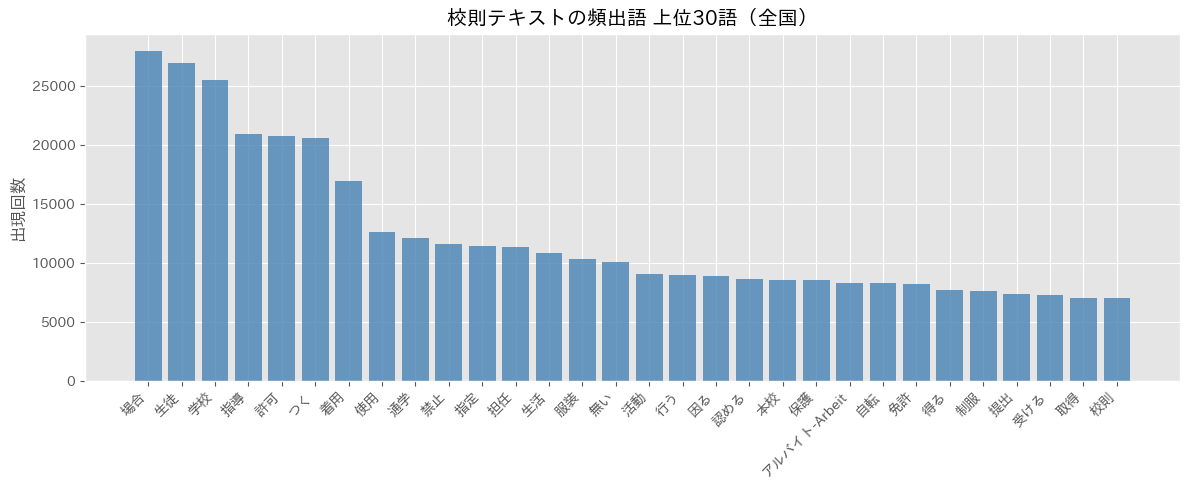

In [ ]:
word_series = pd.Series(word_count_dict)
top30 = word_series.sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top30)), top30.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30.index.tolist(), rotation=45, ha='right')
ax.set_ylabel('出現回数')
ax.set_title('校則テキストの頻出語 上位30語（全国）')
plt.tight_layout()
plt.savefig('fig_scored_total.png', dpi=150)
plt.show()

「許可」「着用」「禁止」「服装」などが上位に並んでおり、校則として適切なテキストが収集できていることが確認できた。

---

## 5.自動アノテーション

先行研究（大森,2023）では条文を手作業で分類した。本研究ではこの手作業を自動化する。

### 5-1.アノテーションの設計

各条文にP（禁止）・O（義務）・R（推奨）・E（例外）・A（曖昧）・OTHER（その他）の６ラベルのいずれかを付与する。各ラベルは単語の表層形ではなく、その表現が生徒をどのように制約・方向づけるかという観点から定義した。

| ラベル | 定義 | 代表的な表現 |
|-------|-------------|-------------|
| P（禁止） | 生徒の行為を直接制限・禁止する | 「禁止する」「してはならない」「認めない」 |
| O（義務） | 学校が特定の行動を義務として要求する | 「~すること」「〜しなければならない」 |
| R（推奨） | 努力目標・望ましい行動を示す | 「心がける」「努める」「望ましい」 |
| E（例外） | 条件付きの許可や裁量を認める | 「ただし」「〜してよい」「可とする」 |
| A（曖昧） | 解釈を学校側に委ねる曖昧な規範を示す | 「高校生らしい」「華美でない」「節度ある」 |
| OTHER （その他）| 上記のいずれにも該当しない | 理念・前文・手続き説明等 |

パターンリストは以下の手順で構築した。まず各ラベルの候補となる表現を列挙し、全ての条文に対して出現件数を集計した。出現頻度が高い表現ほど、校則テキストにおいて安定して使われていると考えられるため、この頻度を根拠としてパターンリストを決定した。

また、辞書は当初P・O・R・Eの４ラベルのみで設計していた。しかし、実際の校則テキストを分析すると、「高校生らしい」「華美でない」など、明示的な禁止ではないものの、解釈を学校に委ねる曖昧なルールが多数存在することが判明した。

これらの表現は、生徒の行動を直接禁止するのではなく、解釈を通じて間接的に行動を方向づける特徴を持つ。このため、本研究ではA（Ambiguous）ラベルを追加し、辞書を更新した。

In [ ]:
#各ラベルの候補表現の出現数を集計する
candidate_patterns = {
    'P': [
        '禁止', 'してはならない', 'しないこと', '禁ずる', '禁じる', 'してはいけない',
        '慎む', '許可なく', '無断で', '厳禁', '控えること', '認めない', '不可',
        'いけない', '行ってはならない', '持ち込まない', 
        '没収', '預かる', '指導の対象','特別指導',
        ],
    'O': [
        'すること', 'しなければならない', 'でなければならない', '遵守', '着用する', 
        '従うこと', 'するものとする', 'を守ること', 'してください', 'するように', 
        'しなくてはならない', '提出すること', '届け出ること', '申し出ること',
        '着用すること', '連絡すること', '行うこと', '注意すること', '指定の', '所定の',
        '厳守', '必ず', 'とする', '義務',
    ],
    'R': [
        '心がける', '努める', '望ましい', 'が好ましい',
        'に努力', '励む', 'よう努める', 'を心がけ', '推奨', '基本とする',
        'に心がける', 'するよう心がけ', 'することが大切', '求められる',
    ],
    'E': [
        'ただし', 'やむを得ない', 'この限りではない', '許可を得',
        'してもよい', 'することができる', 'を除く', '場合に限り', 
        '任意', '自由とする', 'してよい', '認める', 'でもよい',
        '可とする', '許可される', '場合はこの限り', '承認を得た',
        '差し支えない', 'してもかまわない', 'この限りでない',
        '異装', '特例', '特別に', '例外'
    ],
    'A': [
        '高校生らしい', '高校生として', '生徒として', '華美', '節度', '品位', '奇抜',
        'ふさわしい', '常識', '清潔', '端正', '適切', '生徒らしい', '良識', '自然な',
        'にふさわしい', 'にふさわしくない', '高校生らしく', 'マナー', '適切',
        '節度ある', '相応しい', '相応しくない', '社会通念', '見苦しくない',
    ]
}

all_sentences = list()
for sentences in df_schools['sentences']:
    all_sentences.extend(sentences)

for label, patterns in candidate_patterns.items():
    pat_count = dict()
    for pat in patterns:
        count = 0
        for sent in all_sentences:
            if pat in sent:
                count += 1
        pat_count[pat] = count
    sorted_pats = sorted(pat_count.items(), key = lambda x: x[1], reverse=True)
    for pat, count in sorted_pats:
        print(str(count), '件', label, pat)

11073 件 P 禁止
3213 件 P 認めない
3021 件 P しないこと
1794 件 P してはならない
1555 件 P 特別指導
1143 件 P 不可
751 件 P 指導の対象
660 件 P 厳禁
513 件 P 許可なく
496 件 P 無断で
481 件 P いけない
432 件 P 慎む
430 件 P 禁ずる
366 件 P 持ち込まない
274 件 P してはいけない
227 件 P 預かる
98 件 P 行ってはならない
55 件 P 禁じる
53 件 P 没収
38 件 P 控えること
24243 件 O とする
14896 件 O すること
6862 件 O 着用する
6652 件 O 指定の
5388 件 O 必ず
4347 件 O 所定の
2067 件 O 着用すること
1659 件 O してください
1519 件 O しなければならない
1427 件 O 遵守
1041 件 O 提出すること
1020 件 O 行うこと
994 件 O 届け出ること
731 件 O 厳守
597 件 O するものとする
538 件 O を守ること
461 件 O 連絡すること
421 件 O 注意すること
397 件 O 従うこと
387 件 O 義務
378 件 O 申し出ること
288 件 O するように
187 件 O でなければならない
7 件 O しなくてはならない
1622 件 R 努める
1419 件 R 心がける
842 件 R を心がけ
567 件 R に心がける
534 件 R 望ましい
190 件 R に努力
172 件 R よう努める
153 件 R 基本とする
113 件 R 推奨
87 件 R するよう心がけ
80 件 R 励む
34 件 R することが大切
29 件 R 求められる
12 件 R が好ましい
4613 件 E ただし
3294 件 E 許可を得
2691 件 E 認める
1264 件 E 異装
1143 件 E やむを得ない
932 件 E してもよい
827 件 E 可とする
792 件 E することができる
547 件 E 任意
280 件 E を除く
268 件 E でもよい
229 件 E 場合に限り
198 件 E この限りではない
197 件 E 特別に
164 件 E 自由とする


上記の集計結果をもとに、各パターンの出現頻度と実際の条文を確認しながら最終的なパターンリストを確定した。なお、`不可`については「不可欠」「不可能」を誤って検出するリスクがあるため`不可とする`、`は不可`という形で採用した。また`認める`、`任意`については前後の文脈によって意味が変わるため、`を認める`、`任意とする`のように語末まで指定した。

`没収`、`預かる`、`指導の対象`、`特別指導`は禁止そのものではなく違反語の対応を示す表現であるため、Pラベルから除外した。同様に`とする`はOラベルの候補として件数が多いが、「本規定は〇〇とする」のような定義文に頻出するためOTHERの競合が大きく、除外した。

### 5-2.アノテーションの実装

集計結果を踏まえ、最終的なパターンリストを以下のように確定した。ラベルの優勢順位はOTHER（精神条文を早期に除外）→ P → E → O → A → R → OTHER（未分類）とした。EをOより先に判定する理由は、「やむを得ない場合は担任に届け出ること」のようにEとOの両パターンが同時に出現する文ではEを優先すべきであるためである。またOをAより先に判定する理由は、「服装は端正でなければならない」のように義務文の中に曖昧語が含まれる場合、文全体の性格は義務であるためである。

In [ ]:
OTHER_PATS = [
    '目指し', 'の精神に則', 'に貢献' , 'の自覚を持', '人間として',
    'を目的とする', 'の向上を図', '本校生徒は', 'を培う',
]

P_PATS = [
    '禁止', 'してはならない', 'しないこと',
    'を禁ずる', 'してはいけない', '慎む',
    '行ってはならない', '許可なく', '無断で',
    '厳禁', '控えること', '認めない',
    '不可とする', 'は不可', '許可しない',
    'いけない', 'を持ち込まない', '持ち込み禁止',
]

O_PATS = [
    'すること', 'しなければならない', 'でなければならない',
    'を遵守', '着用する', '従うこと',
    'するものとする', 'しなくてはならない', '届け出ること',
    '申し出ること', '提出すること', 'を着用すること',
    '連絡すること', 'を行うこと', '注意すること',
]

R_PATS = [
    '心がける', '努める', '望ましい',
    'が好ましい', 'に努力', '励む',
    'よう心がける', 'を心がけ', 'に心がける',
    'するよう心がけ', 'することが大切',
]

E_PATS = [
    'ただし', 'やむを得ない', 'この限りでない',
    'この限りではない', '許可を得', 'してもよい',
    'することができる', 'を除く', '場合に限り',
    '任意とする', '自由とする', 'してよい',
    'を認める', 'でもよい', '可とする',
    '許可される', '場合はこの限り', '承認を得た',
    '差し支えない', 'してもかまわない',
]

A_PATS = [
    '高校生らしい', '高校生として', '生徒として',
    '華美', '節度', '品位',
    'ふさわしい', '清潔感', '端正',
    '適切', '生徒らしい', 'にふさわしい',
    'にふさわしくない', '高校生らしく', '節度ある',
    '相応しい',  '相応しくない', '社会通念',
    '良識', '見苦しくない',
]

def annotate(sentence):
    for pat in OTHER_PATS:
        if pat in sentence:
            return 'OTHER'
    for pat in P_PATS:
        if pat in sentence:
            return 'P'
    for pat in E_PATS:
        if pat in sentence:
            return 'E'
    for pat in O_PATS:
        if pat in sentence:
            return 'O'
    for pat in A_PATS:
        if pat in sentence:
            return 'A'
    for pat in R_PATS:
        if pat in sentence:
            return 'R'
    return 'OTHER'

In [ ]:
#動作確認
test_cases = [
    ('P', '携帯電話の使用を禁止する。'),
    ('P', 'ジャンバー類の着用は認めない。'),
    ('P', '許可なく外出してはならない。'),
    ('O', '制服を着用すること。'),
    ('O', '服装は質素で端正でなければならない。'),
    ('R', '礼儀正しく行動するよう心がける。'),
    ('E', 'やむを得ない場合は担任に申し出ること。'),
    ('E', 'ただし、学校行事の場合はこの限りでない。'),
    ('E', 'セーターの着用を認める。'),
    ('A', '高校生らしい頭髪を心がけること。'),
    ('A', '華美でない服装とする。'),
    ('OTHER', '本校生徒は豊かな人間性を目指す。'),
]

all_pass = True
for expected, sent in test_cases:
    result = annotate(sent)
    mark = 'OK' if result == expected else 'NG'
    if result != expected:
        all_pass = False
    print(mark, '期待値：', expected, '結果：', result, '文：', sent)
    

OK 期待値： P 結果： P 文： 携帯電話の使用を禁止する。
OK 期待値： P 結果： P 文： ジャンバー類の着用は認めない。
OK 期待値： P 結果： P 文： 許可なく外出してはならない。
OK 期待値： O 結果： O 文： 制服を着用すること。
OK 期待値： O 結果： O 文： 服装は質素で端正でなければならない。
OK 期待値： R 結果： R 文： 礼儀正しく行動するよう心がける。
OK 期待値： E 結果： E 文： やむを得ない場合は担任に申し出ること。
OK 期待値： E 結果： E 文： ただし、学校行事の場合はこの限りでない。
OK 期待値： E 結果： E 文： セーターの着用を認める。
OK 期待値： A 結果： A 文： 高校生らしい頭髪を心がけること。
OK 期待値： A 結果： A 文： 華美でない服装とする。
OK 期待値： OTHER 結果： OTHER 文： 本校生徒は豊かな人間性を目指す。


無事にアノテーションが成功したことを確認した。

### 5-3.全校への適用

以上を踏まえ、全校の校則テキストにアノテーションを施す。

In [ ]:
def count_labels(sentences):
    count_dict = {
        'P': 0,
        'O': 0,
        'R': 0,
        'E': 0,
        'A': 0,
        'OTHER': 0
    }
    for s in sentences:
        label = annotate(s)
        count_dict[label] += 1
    return pd.Series({
        'P_count': count_dict['P'],
        'O_count': count_dict['O'],
        'R_count': count_dict['R'],
        'E_count': count_dict['E'],
        'A_count': count_dict['A'],
        'OTHER_count': count_dict['OTHER'],
    })

label_df = df_schools['sentences'].apply(count_labels)
df_schools = pd.concat([df_schools, label_df], axis=1)

df_schools['scored_total'] = (
    df_schools['P_count'] + df_schools['O_count'] +
    df_schools['R_count'] + df_schools['E_count']
)

以下で、ラベルの分布を確認する。

In [ ]:
totals = df_schools[['P_count', 'O_count', 'R_count', 'E_count', 'A_count', 'OTHER_count']].sum()
total_sum = totals.sum()
scored_sum = totals[['P_count', 'O_count', 'R_count', 'E_count', 'A_count', 'OTHER_count']].sum()

print('全校のラベル合計：')
print(totals)
print('\n各ラベルの割合')
print('P（禁止）の割合：', round(totals['P_count'] / total_sum * 100, 1), '%')
print('O（義務）の割合：', round(totals['O_count'] / total_sum * 100, 1), '%')
print('R（推奨）の割合：', round(totals['R_count'] / total_sum * 100, 1), '%')
print('E（例外）の割合：', round(totals['E_count'] / total_sum * 100, 1), '%')
print('A（曖昧）の割合：', round(totals['A_count'] / total_sum * 100, 1), '%')
print('OTHER（その他）の割合 ：', round(totals['OTHER_count'] / total_sum * 100, 1), '%')


全校のラベル合計：
P_count         22882
O_count         20947
R_count          2843
E_count         12168
A_count          6557
OTHER_count    161885
dtype: int64

各ラベルの割合
P（禁止）の割合： 10.1 %
O（義務）の割合： 9.2 %
R（推奨）の割合： 1.3 %
E（例外）の割合： 5.4 %
A（曖昧）の割合： 2.9 %
OTHER（その他）の割合 ： 71.2 %


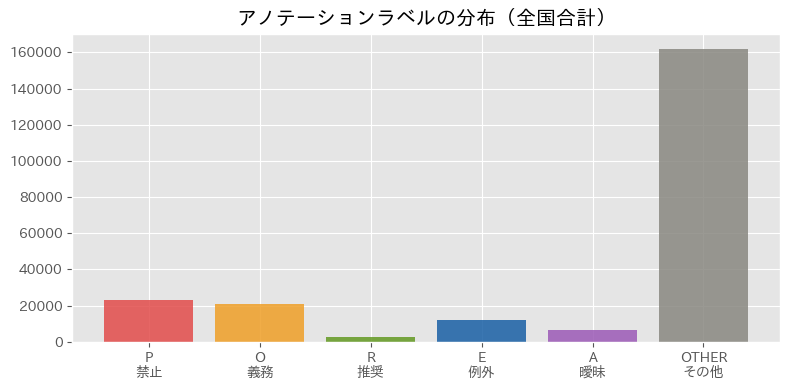

In [ ]:
#分布の可視化
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(['P\n禁止', 'O\n義務', 'R\n推奨', 'E\n例外', 'A\n曖昧', 'OTHER\nその他'],
       totals.values, 
       color=['#E24B4A', '#EF9F27', '#639922', '#185FA5', '#9B59B6', '#888780'], 
       alpha=0.85)
ax.set_title('アノテーションラベルの分布（全国合計）')
plt.tight_layout()
plt.savefig('fig_label_dist.png', dpi=150)
plt.show()

約７割がOTHER（その他）に分類された。当初、この結果はアノテーションの失敗と捉えていたが、校則テキストを確認する中で、この失敗自体が校則の本質を示している可能性に気付いた。校則には禁止や義務だけでなく、理念や教育方針といった記述が大量に含まれている。

---

## 6.自由度スコア

各学校の校則に対して、以下の式で自由度スコアを計算する。  

$$
\text{自由度スコア} 
= \frac{R + 2E}
{2P + O + R + 2E} 
\times 100 
$$

本スコアは、校則テキストにおいて、許容や裁量を認める表現（R・E）が禁止や義務を規定する（P・O）に対してどの程度含まれるかを定量化したものである。そのため、範囲は0~100の範囲で高いほど許容的、低いほど制限的な規定が多いことを示す。

重みについては、P（禁止）は生徒の行動を直接制限する最も強い拘束表現、E（例外）は生徒の裁量を最も明示的に認める表現として、それぞれ重み２を付与した。O（義務）とR（推奨）は拘束や許容ともにPやEより弱い中間的な表現として重み１とした。なおAラベルはスコアに含めず、別途集計する。

ただし、本指標は明文化されたルールを対象としており、そもそも規定が存在しない自由は測定できないという限界を持つ。



### 6-1.閾値の設定

scored_total（P ,O ,R,Eの合計）が10件未満の学校は、分母が極端に小さく、少数の条文によってスコアが大きく変動する可能性がある。

例えば、P=0, E=１のみの場合、スコアは100となるが、これは自由な学校であることを意味するとは限らず、アノテーションの対象となるルールが極端に少ないことに起因する。

このような不安定な値を除外するため、本研究ではscored_totalが10未満の学校を欠損値として分析対象から除外した。閾値はscored_totalのヒストグラムを以下で確認した上で設定した。

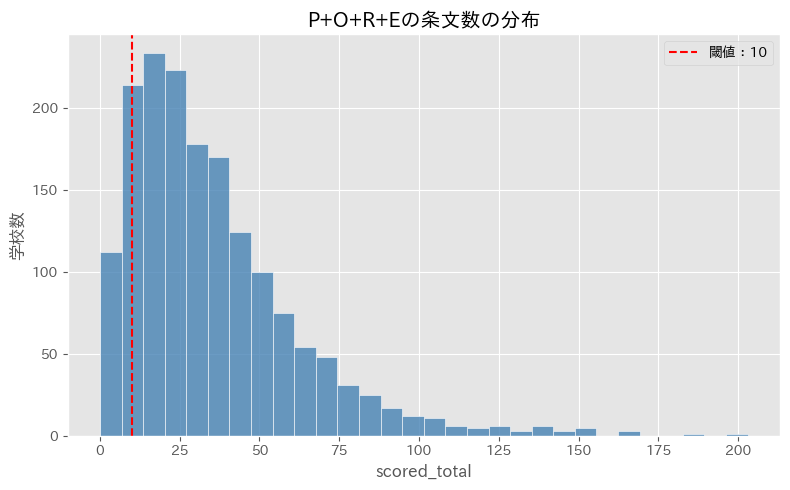

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_schools['scored_total'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='閾値：10')
ax.set_title('P+O+R+Eの条文数の分布')
ax.set_xlabel('scored_total')
ax.set_ylabel('学校数')
ax.legend()
plt.tight_layout()
plt.savefig('fig_sum.png', dpi=150)
plt.show()

### 6-2.自由度スコアの算出

それではいよいよ自由度スコアを算出する。閾値は10であることに注意が必要である。
まず自由度スコア関数を定義する。

In [ ]:
MIN_SCORED = 10

def freedom_score(row):
    if row['scored_total'] < MIN_SCORED:
        return np.nan
    P, O ,R, E = 2, 1, 1, 2
    numer = row['R_count'] * R + row['E_count'] * E
    denom = row['P_count'] * P + row['O_count'] * O + row['R_count'] * R + row['E_count'] * E
    
    if denom == 0:
        return np.nan #分母が0の時を防ぐ
    return round(numer / denom * 100, 2)

自由度スコア関数を全ての校則テキストに適用させる。

In [ ]:
df_schools['freedom_score'] = df_schools.apply(freedom_score, axis=1)

print('自由度スコアの基本統計量')
print(df_schools['freedom_score'].describe().round(2))

自由度スコアの基本統計量
count    1480.00
mean       29.15
std        13.36
min         0.00
25%        19.70
50%        28.00
75%        37.50
max        83.33
Name: freedom_score, dtype: float64


無事に、自由度スコアを算出することができた。スコア化できた校則は1480校であり、186校が閾値により除外された。

### 6-3.自由度スコアの分布

上記で求めた自由度スコアの分布をヒストグラムにより可視化する。

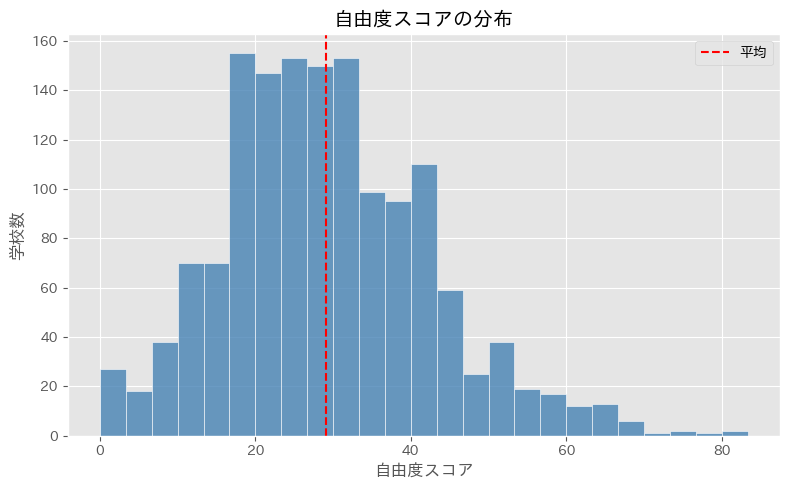

In [ ]:
valid_scores = df_schools.loc[df_schools['freedom_score'].notnull(), 'freedom_score']
mean_score = valid_scores.mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(valid_scores, bins=25, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(mean_score, color='red', linestyle='--', label=f'平均')
ax.set_title('自由度スコアの分布')
ax.set_xlabel('自由度スコア')
ax.set_ylabel('学校数')
ax.legend()
plt.tight_layout()
plt.savefig('fig_freedom_hist.png', dpi=150)
plt.show()

自由度スコアの分布は正規分布に近しい山型になっていることが確認できた。

## 7.偏差値データとの結合

全国校則一覧と高校偏差値.netでは学校名の表記が異なる場合がある。例えば、「札幌北高等学校（全日・定時）」と「札幌北高校」のような違いである。以下の手順で学校名を正規化した後、都道府県と学校名の二変数をキーとして`pd.merge`で結合する。

1. 設置者名（「東京都立」「神奈川県立」等）を`.replace()`で除去
2. 「高等学校」を`.replace`で「高校」に統一
3. 「（」や「（」以降の課程・学科情報を`.split()`で除去

両方のデータセットに存在する学校のみを分析対象とするため、`pd.merge`には注意が必要である。また、同一学校に複数の偏差値がある場合（学科別）は`groupby`で最大値を採用した。全国校則一覧の校則が学科単位ではなく学校単位で記録されているためである。

In [ ]:
INSTALLER = [
    '北海道立', '東京都立', '大阪府立', '京都府立',
    '青森県立', '岩手県立', '宮城県立', '秋田県立', '山形県立', '福島県立',
    '茨城県立', '栃木県立', '群馬県立', '埼玉県立', '千葉県立', '神奈川県立',
    '新潟県立', '富山県立', '石川県立', '福井県立', '山梨県立', '長野県立',
    '静岡県立', '愛知県立', '岐阜県立', '三重県立',
    '滋賀県立', '兵庫県立', '奈良県立', '和歌山県立',
    '鳥取県立', '島根県立', '岡山県立', '広島県立', '山口県立',
    '徳島県立', '香川県立', '愛媛県立', '高知県立',
    '福岡県立', '佐賀県立', '長崎県立', '熊本県立', '大分県立',
    '宮崎県立', '鹿児島県立', '沖縄県立',
    '市立', '区立', '町立', '村立',
]

def normalize_name(name):
    name = str(name)
    for s in INSTALLER:
        name = name.replace(s, '')
    name = name.replace('高等学校', '高校')
    if '（' in name:
        name = name.split('（')[0]
    return name.strip()

In [ ]:
#動作確認
check = [
    ('札幌北高等学校(全日・定時)', '札幌北高校'),
    ('東京都立多摩高等学校', '多摩高校'),
    ('函館中部高等学校(全日・定時)', '函館中部高校'),
]

for before, expected in check:
    result = normalize_name(before)
    print(before, '→', result)

札幌北高等学校(全日・定時) → 札幌北高校(全日・定時)
東京都立多摩高等学校 → 多摩高校
函館中部高等学校(全日・定時) → 函館中部高校(全日・定時)


正規化の動作確認が成功した。いよいよ、全国校則一覧と高校偏差値.netのデータを結合する。

In [ ]:
df_schools['name_norm'] = df_schools['school_name'].apply(normalize_name)
hensachi_did['name_norm'] = hensachi_did['school_name'].apply(normalize_name)

# 同一校に複数の偏差値がある場合は最大値を採用する
df_h_dedup = (
    hensachi_did
    .groupby(['prefecture', 'name_norm'], as_index=False, observed=True)
    .agg(
        hensachi = ('hensachi', 'max'),
        gender = ('gender', 'first'),
        gakka = ('gakka', 'first'),
        did_ratio = ('did_ratio', 'first'),
        location = ('location', 'first'),
    )
)


df_merged = pd.merge(
    df_schools,
    df_h_dedup,
    on=['prefecture', 'name_norm'],
    how='inner'
)

print('校則データ件数：', len(df_schools))
print('偏差値データ件数：', len(df_h_dedup))
print('結合後件数：', len(df_merged))
print('マッチ率：', round(len(df_merged) / len(df_schools) * 100, 1), '%')

校則データ件数： 1666
偏差値データ件数： 3330
結合後件数： 1439
マッチ率： 86.4 %


結合率が86.4%となった主な原因は、分校・通信高校・定時制高校など高校偏差値.netに記載のない学校の存在であった。

次に分析に使用するデータを確定する。偏差値・自由度スコア・DID人口比率の全てが揃っている学校のみに絞り、ダミー変数を作成する。男女別は共学を基準カテゴリとする。専門高校ダミーは学科名に工業・商業・農業等の語が含まれる場合に1とする。

In [ ]:
df = df_merged.loc[
    df_merged['hensachi'].notnull() & 
    df_merged['freedom_score'].notnull() &
    df_merged['did_ratio'].notnull(), :].copy()

df['hensachi'] = df['hensachi'].astype(float)
df['did_ratio'] = df['did_ratio'].astype(float)

df['is_girl'] = df['gender'].apply(lambda x: 1 if x == '女子' else 0)
df['is_boy']  = df['gender'].apply(lambda x: 1 if x == '男子' else 0)

SENMON_WORDS = ['工業', '商業', '農業', '水産', '家政', '看護', '福祉', '芸術', '体育', '理数']
def check_senmon(gakka):
    for s in SENMON_WORDS:
        if s in str(gakka):
            return 1
    return 0

df['is_senmon'] = df['gakka'].apply(check_senmon)


print('基本統計量')
print(df[['hensachi', 'did_ratio', 'is_girl', 'is_boy', 'is_senmon',
        'freedom_score', 'P_count', 'O_count', 'R_count', 'E_count', 'A_count', 'OTHER_count']].describe().round(2))

基本統計量
       hensachi  did_ratio  is_girl   is_boy  is_senmon  freedom_score  \
count   1288.00    1288.00  1288.00  1288.00    1288.00        1288.00   
mean      48.77      50.84     0.01     0.00       0.09          29.35   
std        9.07      37.62     0.10     0.06       0.28          13.20   
min       36.00       0.00     0.00     0.00       0.00           0.00   
25%       41.00      10.68     0.00     0.00       0.00          19.88   
50%       47.00      54.76     0.00     0.00       0.00          28.12   
75%       55.00      88.82     0.00     0.00       0.00          37.74   
max       75.00     100.00     1.00     1.00       1.00          83.33   

       P_count  O_count  R_count  E_count  A_count  OTHER_count  
count  1288.00  1288.00  1288.00  1288.00  1288.00      1288.00  
mean     14.86    13.72     1.79     8.04     4.09       101.63  
std       9.94    11.67     2.11     6.79     3.13        69.22  
min       0.00     0.00     0.00     0.00     0.00        17.00

次項でいよいよデータ分析に入る。

---
## 8.データ分析・可視化

### 9-1.相関行列の確認

分析の前に、主要変数間の相関関係`df.corr()`で確認する。どの変数が自由スコアと関連しているかを俯瞰的に把握する。

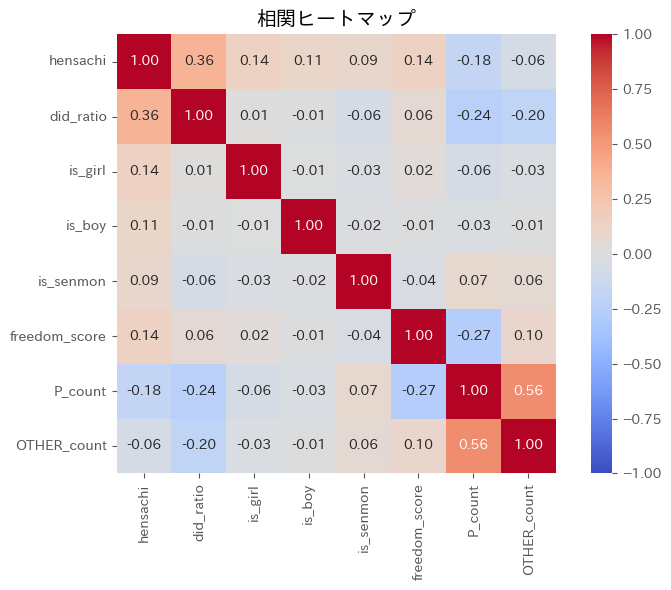

In [ ]:
cols = ['hensachi', 'did_ratio', 'is_girl', 'is_boy', 'is_senmon',
        'freedom_score', 'P_count', 'OTHER_count']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=ax, square=True)

ax.set_title('相関ヒートマップ')
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150)
plt.show()

### 8-2. 重回帰分析（自由度スコア）

以下のモデルで重回帰分析を実施する。

$$\text{自由度スコア} = \beta_0 + \beta_1 \text{偏差値} + \beta_2 \text{DID比率} + \beta_3 \text{女子校} + \beta_4 \text{男子校} + \beta_5 \text{専門高校} + \varepsilon$$

偏差値以外の交絡変数（都市度・学校属性）を統制した上で偏差値の独立した効果を推定することが目的である。使用パッケージはstatsmodels（OLS）。p < 0.05 のとき統計的に有意と判断する。

In [ ]:
X_cols = ['hensachi', 'did_ratio', 'is_girl', 'is_boy', 'is_senmon']
X = df[X_cols].copy()
X = sm.add_constant(X)  # 切片を追加する
y = df['freedom_score']

# 重回帰モデルの推定
model_freedom = sm.OLS(y, X).fit()
print(model_freedom.summary())

                            OLS Regression Results                            
Dep. Variable:          freedom_score   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     6.157
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.20e-05
Time:                        22:23:33   Log-Likelihood:                -5135.1
No. Observations:                1288   AIC:                         1.028e+04
Df Residuals:                    1282   BIC:                         1.031e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.9439      2.034      9.315      0.0

### 8-3. 重回帰分析（禁止条文数）

自由度スコアは複数ラベルを合成した指標であるため、より解釈が明確な禁止条文数（P_count）を従属変数とした同一モデルでも分析を行う。相関ヒートマップで偏差値との相関が最も強いのはP_countであり、「偏差値が高い学校ほど禁止条文が少ない」という命題を直接検証する。

In [ ]:
X_cols = ['hensachi', 'did_ratio', 'is_girl', 'is_boy', 'is_senmon']
X = df[X_cols].copy()
X = sm.add_constant(X)  # 切片を追加する
y = df['P_count']

# 重回帰モデルの推定
model_freedom = sm.OLS(y, X).fit()
print(model_freedom.summary())

                            OLS Regression Results                            
Dep. Variable:                P_count   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     20.40
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.24e-19
Time:                        22:23:33   Log-Likelihood:                -4735.1
No. Observations:                1288   AIC:                             9482.
Df Residuals:                    1282   BIC:                             9513.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.9415      1.491     15.388      0.0

### 9-4. 多重共線性の確認（VIF）

重回帰分析の前提として、説明変数間に強い多重共線性がないことを確認する。VIF（分散拡大係数）が10を超える場合は問題となる可能性がある。

In [ ]:
X_vif = sm.add_constant(df[X_cols].copy())
vif_df = pd.DataFrame()
vif_df['variable'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]

print(vif_df.to_string(index=False))

 variable       VIF
    const 31.189408
 hensachi  1.207999
did_ratio  1.165500
  is_girl  1.023098
   is_boy  1.016188
is_senmon  1.020705


### 9-5. 偏差値帯別の分析

`pd.cut` で偏差値を6段階にカテゴリ化し、各グループの平均自由度スコアとラベル構成比を `groupby` + `agg` で集計・可視化する。回帰分析の結果を補完する形で、偏差値帯ごとの傾向を確認することが目的である。

In [ ]:
df['hensachi_band'] = pd.cut(
    df['hensachi'],
    bins=[0, 44, 49, 54, 59, 64, 100],
    labels=['44以下', '45-49', '50-54', '55-59', '60-64', '65以上']
)

band_summary = df.groupby('hensachi_band', observed=True).agg(
    n = ('freedom_score', 'count'),
    score_mean = ('freedom_score', 'mean'),
    score_std = ('freedom_score', 'std'),
    P_mean = ('P_count', 'mean'),
    did_mean = ('did_ratio', 'mean')
).round(2)

print(band_summary)

                 n  score_mean  score_std  P_mean  did_mean
hensachi_band                                              
44以下           542       27.67      13.27   16.14     36.63
45-49          250       28.27      12.38   15.69     52.82
50-54          170       30.52      12.45   15.14     61.30
55-59          126       32.03      13.67   12.68     61.74
60-64           96       32.20      11.76   12.83     68.85
65以上           104       32.90      14.97   10.18     73.15


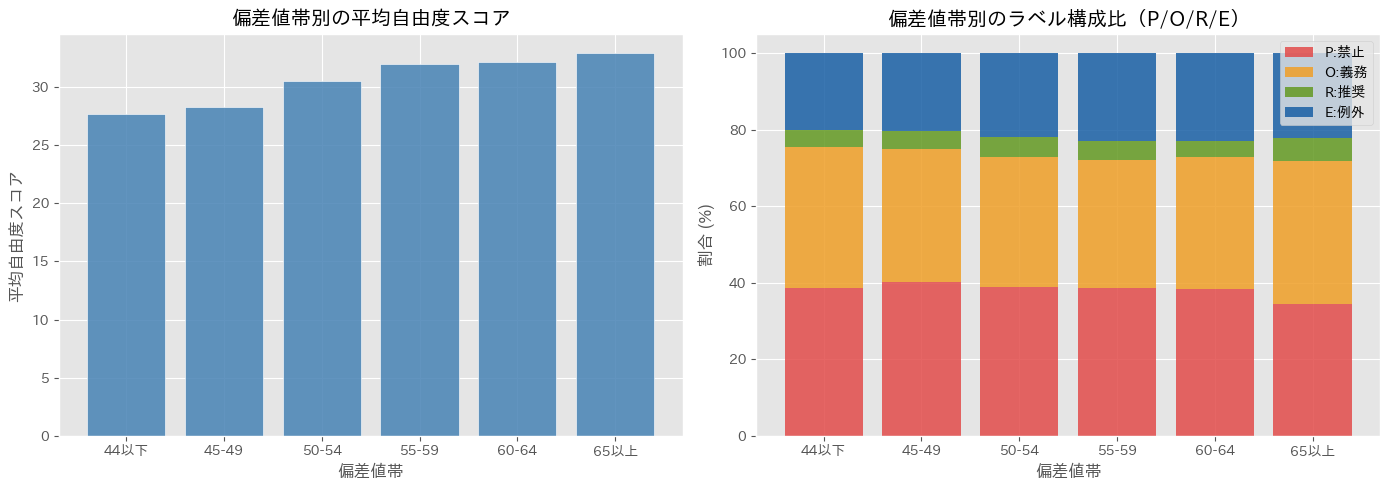

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左：偏差値帯別の平均自由度スコア
band_labels = band_summary.index.tolist()
ax1.bar(band_labels, band_summary['score_mean'].tolist(),
        color='steelblue', alpha=0.85, edgecolor='white')
ax1.set_title('偏差値帯別の平均自由度スコア')
ax1.set_xlabel('偏差値帯')
ax1.set_ylabel('平均自由度スコア')

# 右：ラベル構成比の積み上げ棒グラフ
ratio = df.groupby('hensachi_band', observed=True)[
    ['P_count', 'O_count', 'R_count', 'E_count']].mean()
ratio_pct = ratio.div(ratio.sum(axis=1), axis=0) * 100

bottoms = [0.0] * len(ratio_pct)
for col, color, lname in zip(
    ['P_count', 'O_count', 'R_count', 'E_count'],
    ['#E24B4A', '#EF9F27', '#639922', '#185FA5'],
    ['P:禁止', 'O:義務', 'R:推奨', 'E:例外']
):
    vals = ratio_pct[col].tolist()
    ax2.bar(ratio_pct.index.tolist(), vals, bottom=bottoms,
            color=color, alpha=0.85, label=lname)
    bottoms = [bottoms[i] + vals[i] for i in range(len(vals))]

ax2.set_title('偏差値帯別のラベル構成比（P/O/R/E）')
ax2.set_xlabel('偏差値帯')
ax2.set_ylabel('割合 (%)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fig_band_analysis.png', dpi=150)
plt.show()

### 9-6. 散布図（偏差値 × 自由度スコア）

偏差値と自由度スコアの関係を散布図で可視化する。

In [ ]:
X_simple = sm.add_constant(df[['hensachi']].copy())
y = df['freedom_score']

# 単回帰モデルの推定
model_simple = sm.OLS(y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          freedom_score   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     26.98
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.39e-07
Time:                        22:23:33   Log-Likelihood:                -5137.0
No. Observations:                1288   AIC:                         1.028e+04
Df Residuals:                    1286   BIC:                         1.029e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.1730      1.993      9.621      0.0

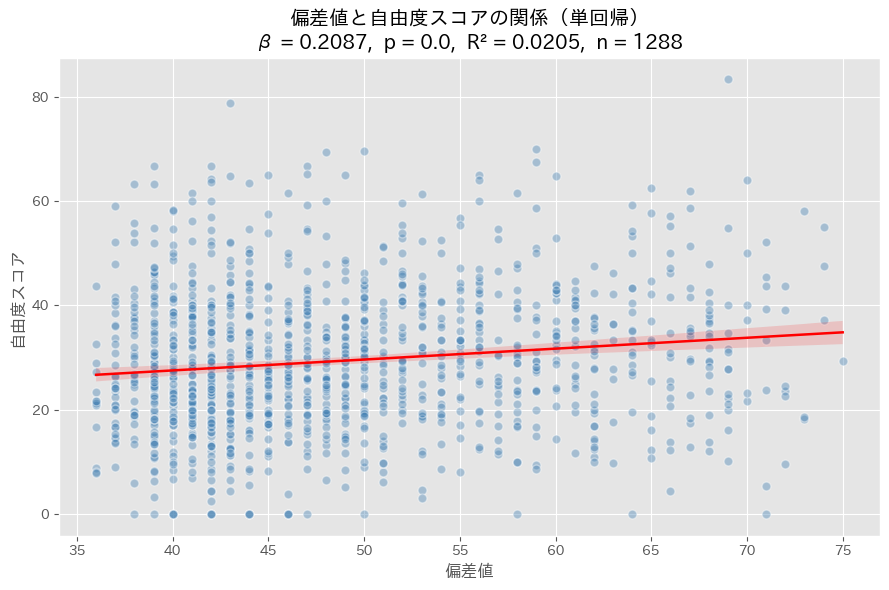

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(x='hensachi', y='freedom_score', data=df,
            scatter_kws={'alpha': 0.4, 's': 40, 'color': 'steelblue', 'edgecolors': 'white'},
            line_kws={'color': 'red', 'linewidth': 1.8},
            ci=95, ax=ax)
ax.set_title(
    '偏差値と自由度スコアの関係（単回帰）\n'
    + 'β = ' + str(round(model_simple.params['hensachi'], 4))
    + ',  p = ' + str(round(model_simple.pvalues['hensachi'], 4))
    + ',  R² = ' + str(round(model_simple.rsquared, 4))
    + ',  n = ' + str(len(df))
)
ax.set_xlabel('偏差値')
ax.set_ylabel('自由度スコア')
plt.tight_layout()
plt.savefig('fig_scatter_main.png', dpi=150)
plt.show()